# Setup & Imports

In [1]:
# ============================================================
# SETUP: Install required libraries
# ============================================================
# Run this cell once. On a local machine with GPU, tensorflow
# should already be installed. We skip tensorflow-datasets
# since we load the flood dataset from local files.

import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Only install if not already present
try:
    import kaggle
except ImportError:
    pip_install('kaggle')

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# ============================================================
# Keras 3.x compatibility helper
# ============================================================
def get_layer_shape(layer):
    """Get output shape compatible with both Keras 2.x and 3.x."""
    try:
        return layer.output_shape
    except AttributeError:
        return layer.output.shape


TensorFlow version: 2.10.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Constants & Configuration

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
IMG_SIZE = 640    # For full training

BATCH_SIZE = 8               # Reduce to 4 if you get OOM at 640x640
BUFFER_SIZE = 300
NUM_CLASSES = 2              # 0 = Background, 1 = Flood

EPOCHS_SIMPLE = 5    # Quick demo
EPOCHS_FULL   = 20   # Full training (requirement: min 20)

CLASS_NAMES = ['Background', 'Flood']
# Background = blue, Flood = orange
COLORMAP = np.array([[30, 100, 200], [255, 140, 0]], dtype=np.uint8)

# Dataset path — will be set after download
DATA_DIR = './flood_data'
IMAGE_DIR = os.path.join(DATA_DIR, 'Image')
MASK_DIR  = os.path.join(DATA_DIR, 'Mask')

print(f"IMG_SIZE:    {IMG_SIZE}x{IMG_SIZE}")
print(f"BATCH_SIZE:  {BATCH_SIZE}")
print(f"NUM_CLASSES: {NUM_CLASSES} → {CLASS_NAMES}")


IMG_SIZE:    640x640
BATCH_SIZE:  8
NUM_CLASSES: 2 → ['Background', 'Flood']


# Load Dataset

In [3]:
# ============================================================
# Download Flood Area Segmentation dataset via Kaggle API
# ============================================================

import os, zipfile

# Verify kaggle.json exists
kaggle_config = os.path.expanduser('~/.kaggle/kaggle.json')
if not os.path.exists(kaggle_config):
    raise FileNotFoundError(
        f"kaggle.json not found at {kaggle_config}\n"
        "Download it from kaggle.com → Account → API → Create New Token"
    )

os.chmod(kaggle_config, 0o600)  # Secure the file (Linux/Mac)
print(f"✅ kaggle.json found at {kaggle_config}")

# Download (skip if already downloaded)
zip_path = 'flood-area-segmentation.zip'
if not os.path.exists(zip_path):
    print("Downloading dataset from Kaggle...")
    os.system('kaggle datasets download -d faizalkarim/flood-area-segmentation')
    print("✅ Download complete")
else:
    print("✅ Already downloaded — skipping")

# Unzip
if not os.path.exists(DATA_DIR):
    print(f"Unzipping to {DATA_DIR}...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    print("✅ Unzip complete")
else:
    print(f"✅ Already extracted to {DATA_DIR}")

# Verify structure
image_files = sorted(glob.glob(os.path.join(IMAGE_DIR, '*')))
mask_files  = sorted(glob.glob(os.path.join(MASK_DIR, '*')))

print(f"\nDataset structure:")
print(f"  Images: {len(image_files)} files in {IMAGE_DIR}")
print(f"  Masks:  {len(mask_files)} files in {MASK_DIR}")

# Show a few filenames
print(f"\nSample image files: {[os.path.basename(f) for f in image_files[:3]]}")
print(f"Sample mask files:  {[os.path.basename(f) for f in mask_files[:3]]}")


✅ kaggle.json found at C:\Users\ERIC/.kaggle/kaggle.json
✅ Already downloaded — skipping
✅ Already extracted to ./flood_data

Dataset structure:
  Images: 290 files in ./flood_data\Image
  Masks:  290 files in ./flood_data\Mask

Sample image files: ['0.jpg', '1.jpg', '10.jpg']
Sample mask files:  ['0.png', '1.png', '10.png']


# Build Dataset, split train/val/test

In [4]:
# ============================================================
# Match image ↔ mask pairs and do train/val/test split
# ============================================================
# The Flood dataset stores images in Image/ and masks in Mask/
# Filenames correspond: Image/0001.jpg ↔ Mask/0001.png (verify below)

import re

def get_stem(path):
    """Return filename without extension."""
    return os.path.splitext(os.path.basename(path))[0]

# Build matched pairs
image_stems = {get_stem(f): f for f in sorted(glob.glob(os.path.join(IMAGE_DIR, '*')))}
mask_stems  = {get_stem(f): f for f in sorted(glob.glob(os.path.join(MASK_DIR,  '*')))}

common_stems = sorted(set(image_stems.keys()) & set(mask_stems.keys()))
print(f"Matched image-mask pairs: {len(common_stems)}")

image_paths = [image_stems[s] for s in common_stems]
mask_paths  = [mask_stems[s]  for s in common_stems]

# Manual split: 70% train, 15% val, 15% test
n = len(image_paths)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

# Shuffle with fixed seed before splitting
rng = np.random.RandomState(42)
idx = rng.permutation(n)
image_paths = [image_paths[i] for i in idx]
mask_paths  = [mask_paths[i]  for i in idx]

train_imgs, train_masks = image_paths[:n_train],         mask_paths[:n_train]
val_imgs,   val_masks   = image_paths[n_train:n_train+n_val], mask_paths[n_train:n_train+n_val]
test_imgs,  test_masks  = image_paths[n_train+n_val:],   mask_paths[n_train+n_val:]

print(f"\nSplit summary:")
print(f"  Train: {len(train_imgs)} images")
print(f"  Val:   {len(val_imgs)} images")
print(f"  Test:  {len(test_imgs)} images")


Matched image-mask pairs: 290

Split summary:
  Train: 203 images
  Val:   43 images
  Test:  44 images


# Pre Processing

In [5]:
# ============================================================
# Preprocessing: load, resize, normalize image + mask
# ============================================================

def load_image(path):
    """Load and decode a JPEG/PNG image."""
    raw = tf.io.read_file(path)
    # Try JPEG first (images), fallback handles PNG
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    return img

def load_mask(path):
    """Load and decode a mask image (grayscale)."""
    raw = tf.io.read_file(path)
    msk = tf.image.decode_image(raw, channels=1, expand_animations=False)
    msk.set_shape([None, None, 1])
    return msk

def preprocess(img_path, msk_path):
    """Load, resize, and normalize an image-mask pair.
    
    Returns:
        image: float32 [IMG_SIZE, IMG_SIZE, 3] in [0, 1]
        mask:  int32   [IMG_SIZE, IMG_SIZE, 1] with values 0 or 1
    """
    image = load_image(img_path)
    mask  = load_mask(msk_path)

    # Resize — NEAREST_NEIGHBOR for mask to preserve binary values
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    mask  = tf.image.resize(mask,  (IMG_SIZE, IMG_SIZE),
                            method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    # Normalize image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    # Binarize mask: 255 → 1, 0 → 0
    mask = tf.cast(mask > 127, tf.int32)

    return image, mask

# Build tf.data datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_imgs, train_masks)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_imgs, val_masks)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_imgs, test_masks)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Verify shapes and dtypes
for image, mask in train_dataset.take(1):
    print(f"Image shape:  {image.shape}, dtype: {image.dtype}")
    print(f"Mask shape:   {mask.shape},  dtype: {mask.dtype}")
    print(f"Image range:  [{image.numpy().min():.2f}, {image.numpy().max():.2f}]")
    print(f"Mask unique values: {np.unique(mask.numpy())}  (expected: [0, 1])")


Image shape:  (640, 640, 3), dtype: <dtype: 'float32'>
Mask shape:   (640, 640, 1),  dtype: <dtype: 'int32'>
Image range:  [0.00, 1.00]
Mask unique values: [0 1]  (expected: [0, 1])


# Explore the Data

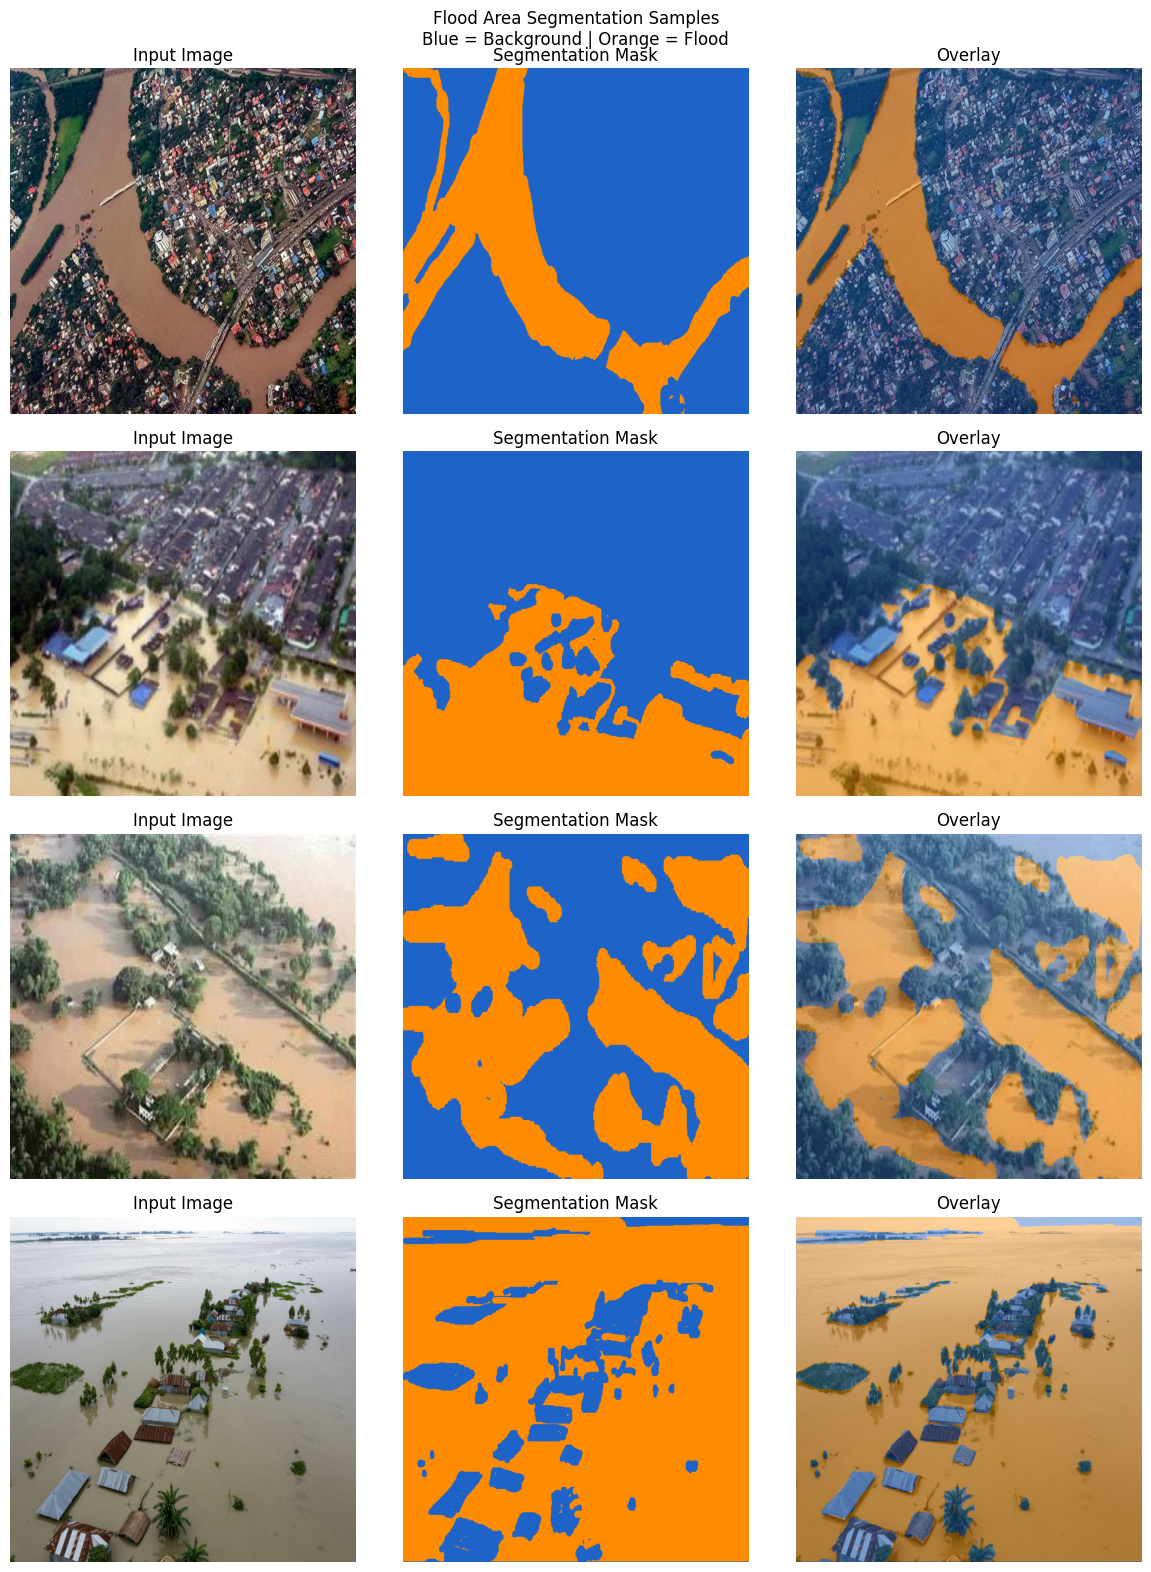

In [6]:
# ============================================================
# Visualize samples: image, mask, and overlay
# ============================================================

def display_sample(images, masks, num_samples=4, title='Flood Area Segmentation Samples'):
    """Display images alongside their flood segmentation masks."""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        mask_colored = COLORMAP[masks[i].squeeze().astype(int)]

        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask_colored)
        axes[i, 1].set_title('Segmentation Mask')
        axes[i, 1].axis('off')

        # Semi-transparent overlay
        overlay = np.clip(images[i] * 0.6 + mask_colored / 255.0 * 0.4, 0, 1)
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')

    plt.suptitle(f'{title}\nBlue = Background | Orange = Flood', fontsize=12)
    plt.tight_layout()
    plt.show()

# Collect samples
sample_images, sample_masks = [], []
for img, msk in train_dataset.take(4):
    sample_images.append(img.numpy())
    sample_masks.append(msk.numpy())

display_sample(sample_images, sample_masks)


In [7]:
# ============================================================
# Class distribution analysis
# ============================================================

# Note: Segmentation datasets are often imbalanced.
# Background pixels typically dominate. This matters for loss functions.

class_counts = np.zeros(NUM_CLASSES)
num_analyzed = 0

for image, mask in train_dataset.take(100):  # Analyze first 100 images
    mask_np = mask.numpy().astype(int).flatten()
    for c in range(NUM_CLASSES):
        class_counts[c] += np.sum(mask_np == c)
    num_analyzed += 1

total_pixels = class_counts.sum()
print(f"\nClass distribution (analyzed {num_analyzed} images):")
print(f"{'Class':<15} {'Count':>12} {'Percentage':>10}")
print(f"{'-'*40}")
for i, name in enumerate(CLASS_NAMES):
    pct = class_counts[i] / total_pixels * 100
    print(f"{name:<15} {class_counts[i]:>12,.0f} {pct:>9.1f}%")

# Calculate class weights (inverse frequency)
class_weights = total_pixels / (NUM_CLASSES * class_counts)
print(f"\nSuggested class weights: {dict(zip(CLASS_NAMES, np.round(class_weights, 2)))}")

InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required.
	 [[{{node decode_image/DecodeImage}}]] [Op:IteratorGetNext]

# Helper Functions

In [13]:
# ============================================================
# Helper: Encoder block (Conv → Conv → MaxPool)
# ============================================================

# Define reusable building blocks, then assemble the full architecture.

def encoder_block(inputs, num_filters):
    """Encoder block: Conv2D → BN → ReLU → Conv2D → BN → ReLU → MaxPool.
    Returns: skip connection output AND pooled output."""
    x = layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    skip = x  # Save for skip connection BEFORE pooling
    pool = layers.MaxPooling2D(2)(x)

    return skip, pool

def decoder_block(inputs, skip, num_filters):
    """Decoder block: UpConv → Concatenate(skip) → Conv2D → BN → ReLU → Conv2D → BN → ReLU."""
    x = layers.Conv2DTranspose(num_filters, 2, strides=2, padding='same')(inputs)
    x = layers.Concatenate()([x, skip])  # Skip connection!

    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x

def bottleneck_block(inputs, num_filters):
    """Bottleneck: Conv2D → BN → ReLU → Conv2D → BN → ReLU (no pooling)."""
    x = layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x

print("✅ Building blocks defined: encoder_block, decoder_block, bottleneck_block")

✅ Building blocks defined: encoder_block, decoder_block, bottleneck_block


In [14]:
# ============================================================
# Build SIMPLIFIED U-Net (3 encoder + 3 decoder blocks)
# ============================================================

def build_simple_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Simplified U-Net with 3 encoder/decoder blocks."""
    inputs = layers.Input(shape=input_shape)

    # --- ENCODER (downsampling path) ---
    skip1, pool1 = encoder_block(inputs, 32)   # 256→128
    skip2, pool2 = encoder_block(pool1, 64)     # 128→64
    skip3, pool3 = encoder_block(pool2, 128)    # 64→32

    # --- BOTTLENECK ---
    bn = bottleneck_block(pool3, 256)            # 32×32×256

    # --- DECODER (upsampling path) ---
    d3 = decoder_block(bn, skip3, 128)           # 32→64
    d2 = decoder_block(d3, skip2, 64)            # 64→128
    d1 = decoder_block(d2, skip1, 32)            # 128→256

    # --- OUTPUT ---
    # 1×1 convolution to map to num_classes channels
    outputs = layers.Conv2D(num_classes, 1, activation='softmax', padding='same')(d1)

    model = models.Model(inputs, outputs, name='Simple_UNet')
    return model

# Build and compile
simple_unet = build_simple_unet()
simple_unet.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Summary
print(f"\n{'='*50}")
print(f"SIMPLIFIED U-NET SUMMARY")
print(f"{'='*50}")
print(f"Total parameters: {simple_unet.count_params():,}")
print(f"Input shape:  {simple_unet.input_shape}")
print(f"Output shape: {simple_unet.output_shape}")
print(f"\n✅ Output shape matches input spatial dimensions — correct!")
print(f"✅ Output has {NUM_CLASSES} channels (one per class) — correct!")


SIMPLIFIED U-NET SUMMARY
Total parameters: 1,931,266
Input shape:  (None, 640, 640, 3)
Output shape: (None, 640, 640, 2)

✅ Output shape matches input spatial dimensions — correct!
✅ Output has 2 channels (one per class) — correct!


In [23]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print("Found a GPU with the name:", gpu)
else:
    print("Failed to detect a GPU.")


Failed to detect a GPU.
